In [49]:
from pyfiles.preamble import *
enable_autoreload()

# pick group for all
case_year = var_groups.shock

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Decomposition of costs between scenarios

The shock scenario replaces approx. 1,740 MW of offshore wind with a 1000 MW nuclear unit. This notebook traces the resulting change in total annual system costs through four cost components and assembles the results into a waterfall chart.

**Contents:**
1. [**Investment costs and O&M**](#1-investment-costs-and-om)     — annualised capital and fixed operating costs by technology
2. [**Fuel and marginal operation**](#2-fuel-and-marginal-operation)  — variable fuel costs and marginal operating costs
3. [**System costs**](#3-system-costs)                 — grid integration cost adjustment for VRE and nuclear
4. [**Import costs**](#4-import-costs-sanity-check)                 — net electricity exchange balance (sanity check)
5. [**Waterfall figure**](#5-waterfall-figure)             — combined decomposition chart

## 1. Investment costs and O&M

Annualised investment and fixed O&M costs are loaded from the investment overview parquet for each scenario. The difference isolates which technologies drive the capital cost change.

*get investment costs for all technologies where these vary across scenarios*

In [50]:
df = [costs.waterfall_inv(f) for f in case_year]
df_all = pd.concat(df)

# 1. compute difference
w = df_all.pivot_table(index="variable", columns="run", values="annuity", aggfunc="sum")
w["annuity_diff"] =  w[case_year[1]] - w[case_year[0]]

# 2. set up dict
d1 = w["annuity_diff"].to_dict()
d1 = {k: v for k, v in d1.items() if v != 0}

# 3. print
print('\n=================================================================')
print('INVESTMENT and O&M:')
for var, diff in sorted(d1.items(), key=lambda kv: abs(kv[1]), reverse=True):
    print(f"{var:<22}{diff:>10.1f} MEUR")

print(f'Summing to: {sum(d1.values()):.2f} MEUR')


INVESTMENT and O&M:
Nuclear                    420.0 MEUR
Wind offshore             -296.0 MEUR
El1 storage cap            -39.0 MEUR
Indust. CHP Heat            10.0 MEUR
Electrolyser                 4.0 MEUR
Large Power Plants          -3.0 MEUR
Hydrogen Storage            -1.0 MEUR
Summing to: 95.00 MEUR


## 2. Fuel and marginal operation

Variable costs cover fuel expenditure (split into gas exchange and other fuel) and marginal operating costs. These are read from the scalar output parquet.

In [51]:
df_ = [costs.waterfall_var(f) for f in case_year]
df_all_ = pd.concat(df_)

# 1. compute difference
w = df_all_.pivot_table(index="variable_costs", columns="run", values="MEUR", aggfunc="sum")
w["annuity_diff"] = w[case_year[1]] - w[case_year[0]]

# 2. set up dict
d2 = w["annuity_diff"].to_dict()

# 3. print
print('\n=================================================================')
print('FUEL and MC:')
for var, diff in sorted(d2.items(), key=lambda kv: abs(kv[1]), reverse=True):
    print(f"{var:.<50}{diff:>10.1f} MEUR")

print(f'Summing to: {sum(d2.values()):.2f} MEUR')


FUEL and MC:
Marginal operation costs..........................      74.0 MEUR
Fuel ex. Ngas exchange............................      47.0 MEUR
Electricity exchange..............................     -40.0 MEUR
Ngas Exchange costs...............................     -30.0 MEUR
CO2 emission costs................................       0.0 MEUR
Summing to: 51.00 MEUR


In [52]:
d2['Fuel ex. Ngas exchange (after CHSP corr.)'] = d2['Fuel ex. Ngas exchange']

print(f'Fuel ex. Ngas exchange: {d2["Fuel ex. Ngas exchange (after CHSP corr.)"]:.0f} MEUR')

Fuel ex. Ngas exchange: 47 MEUR


## 3. System costs

Following the ET working paper on VRE system costs, an external grid integration cost is applied to the change in VRE and nuclear production. The VRE rate (155 DKK/MWh) reflects balancing and grid reinforcement; the nuclear rate (10 DKK/MWh) is much lower, reflecting its dispatchable profile.

In [53]:
out = pd.concat([ep_run_v2.ann_T(f) for f in case_year], axis=1)

base_stem  = Path(case_year[0]).stem   # 'ETT_base_v3'
shock_stem = Path(case_year[1]).stem   # 'ETT_shock_v3'

# 1. yearly production
ve_prod_b = out.loc['Offshore_Electr.'][base_stem]  + out.loc['Wind_Electr.'][base_stem]  + out.loc['PV_Electr.'][base_stem]
ve_prod_s = out.loc['Offshore_Electr.'][shock_stem] + out.loc['Wind_Electr.'][shock_stem] + out.loc['PV_Electr.'][shock_stem]

ve_prod_diff = ve_prod_s - ve_prod_b
kk_prod_diff = out.loc['Nuclear_Electr.'][shock_stem]

# 2. associated costs
sys_costs_ve = ve_prod_diff * (155 / 7.45) * 1e-6 * 1e6
sys_costs_kk = kk_prod_diff * ( 10 / 7.45) * 1e-6 * 1e6

d2['net_sys_VE']  = sys_costs_ve
d2['net_sys_NUC'] = sys_costs_kk
d2['Delta_sys'] = sys_costs_kk + sys_costs_ve

print('\n=================================================================')
print('Add system costs:')
print(f'  VE prod:  base={ve_prod_b:.2f} TWh  shock={ve_prod_s:.2f} TWh  diff={ve_prod_diff:.2f} TWh')
print(f'  KK prod:  {kk_prod_diff:.2f} TWh (shock only)')
print(f'Delta system costs: {d2["Delta_sys"]:.2f} MEUR')


Add system costs:
  VE prod:  base=84.24 TWh  shock=79.41 TWh  diff=-4.83 TWh
  KK prod:  5.10 TWh (shock only)
Delta system costs: -93.64 MEUR


## 4. Import costs (sanity check)

EnergyPLAN's `Electricity exchange` line is already part of `Variable costs` → `TOTAL ANNUAL COSTS` (confirmed by inspecting the raw ASCII output: `Variable costs = Fuel ex. Ngas exchange + Ngas Exchange costs + Marginal operation costs + Electricity exchange + CO2 emission costs`). It is captured via `costs.waterfall_var()` in section 2 (folded into `Fleks. & Stab.`) and must **not** be added again here. This cell is kept only as a cross-check against the value already inside `d2`.

*Electricity exchange cost (shock minus base) from the scalar output. A positive value means the shock scenario incurs higher net import costs.*

In [54]:
# 2. cross-check only — already inside d2['Electricity exchange'], not added again
ep_import_base  = ep_run_v2.load_scalars(case_year[0])['elec_exchange_MEUR']
ep_import_shock = ep_run_v2.load_scalars(case_year[1])['elec_exchange_MEUR']
ep_import_diff  = ep_import_shock - ep_import_base

print(f'  EP import diff (shock-base): {ep_import_diff:.2f} MEUR  (cross-check vs. d2["Electricity exchange"])')

  EP import diff (shock-base): -40.00 MEUR  (cross-check vs. d2["Electricity exchange"])


## 5. Waterfall figure

All cost components are merged into a single dictionary and mapped to display categories via `var_groups.waterfall_dict_full`. The chart is produced in both absolute (M EUR) and relative (% of base total annual cost) form.

*Load total annual costs for both scenarios — used to verify that the decomposition sums to the observed total cost difference.*

In [55]:
df = [costs.get_costs(f) for f in case_year]
all_ = pd.concat(df)

In [56]:
# 1. merge dict, keep only essential
d3 = d1 | d2

# fold CO2 emission costs into marginal operation costs (both driven by dispatch)
d3["Marginal operation costs"] = d3.get("Marginal operation costs", 0) + d3.pop("CO2 emission costs", 0)

# combine Fleksibilitet + Stabilitet into one bar
d3["Fleks. & Stab."] = (
    d3.pop("Electrolyser", 0) + d3.pop("El1 storage cap", 0) + d3.pop("Large Power Plants", 0)  
    + d3.pop("Hydrogen Storage", 0) 
    + d3.pop("Ngas Exchange costs", 0)
    + d3.pop("Electricity exchange", 0)
)

base_TAC  = all_['TOTAL ANNUAL COSTS'].iloc[0]
shock_TAC = all_['TOTAL ANNUAL COSTS'].iloc[1]

# adjusted TAC: TAC − CSHP inv + system costs (elec. exchange already inside TAC — no separate term)
cshp_inv      = d1.get('Indust. CHP Heat', 0)   # shock only; base = 0
adj_base_TAC  = base_TAC  + ve_prod_b * (145 / 7.45)
adj_shock_TAC = shock_TAC - cshp_inv + ve_prod_s * (145 / 7.45) + kk_prod_diff * (10 / 7.45)

print(f'Base  (adj.): {adj_base_TAC:.0f} MEUR')
print(f'Shock (adj.): {adj_shock_TAC:.0f} MEUR')
print(f'Delta (adj.): {adj_shock_TAC - adj_base_TAC:+.0f} MEUR')

Base  (adj.): 25406 MEUR
Shock (adj.): 25454 MEUR
Delta (adj.): +49 MEUR



Waterfall with absolute numbers: ================================
Table: detailed decomposition (MEUR)


,KK inv.,MC,Brændsel,Havvind inv.,Fleks. & Stab.,Systemomk.,Bottom line
Value,420.0,74.0,47.0,-296.0,-109.0,-93.64,42.36


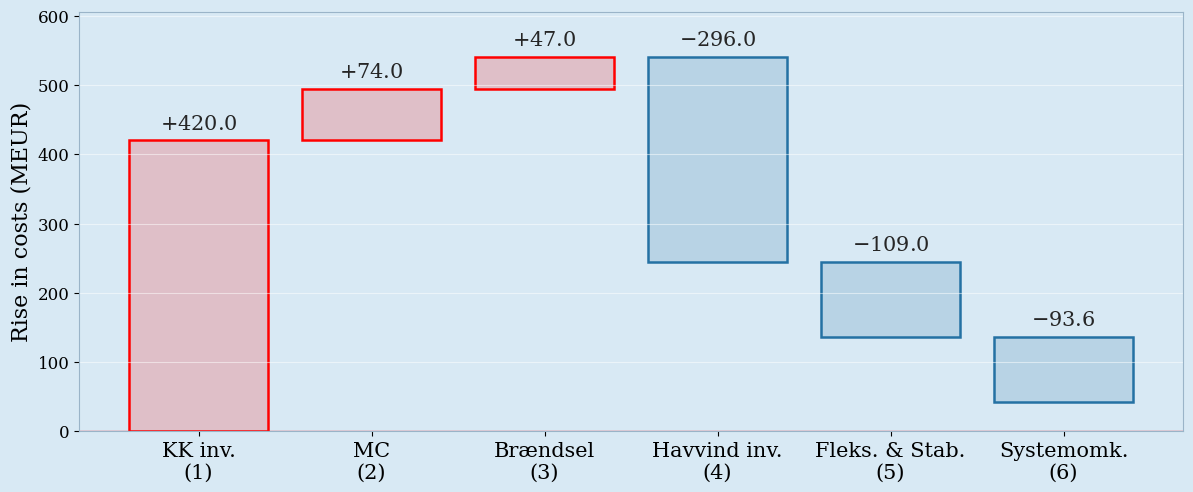


Waterfall with relative numbers: ================================
Table: detailed decomposition (%)


,KK inv.,MC,Brændsel,Havvind inv.,Fleks. & Stab.,Systemomk.,Bottom line
Value,1.65,0.29,0.18,-1.17,-0.43,-0.37,0.17


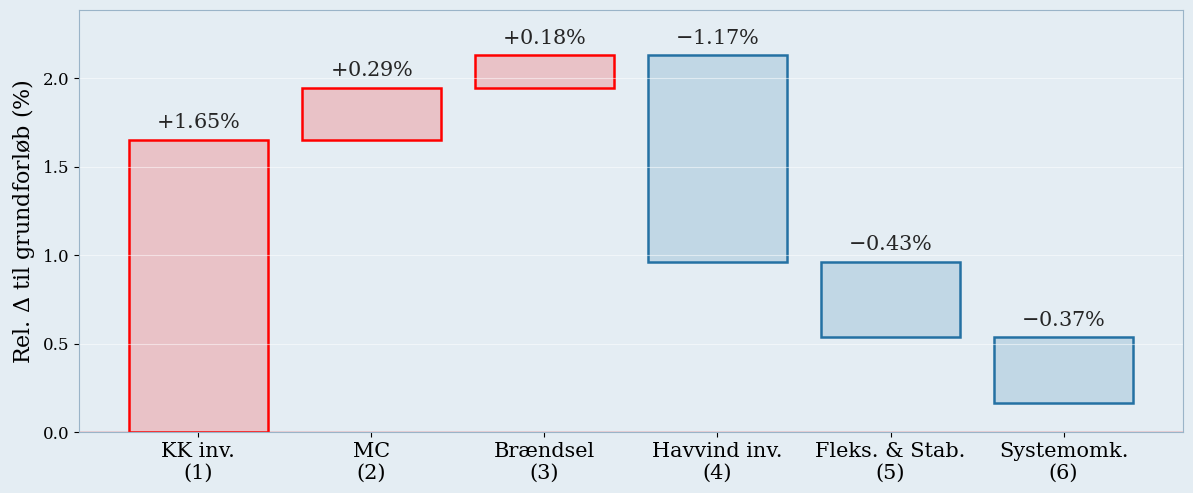

In [57]:
print('\nWaterfall with absolute numbers: ================================')
fig, ax, df_plot, df_table = wf.plot_waterfall(
    d3, var_groups.waterfall_dict_full,
    base_color="#3A3A3A",
    show_delta=True,
    delta_fmt="{:+.1f}",   # MEUR label format
    show_table=True,
    table_round=2,
    table_title="Table: detailed decomposition (MEUR)",
    figsize=(12, 5),
    bg_color="#d8e9f4",
    pos_color="#FF0000",
    neg_color="#2471A3",
)
fig.savefig("0_figurs/abs_omkostningsdekomponering.png", bbox_inches="tight", dpi=300)
plt.show()

print('\nWaterfall with relative numbers: ================================')
# denom = base_TAC        # EP TOTAL ANNUAL COSTS
denom = adj_base_TAC  # TC5 at base: TAC + VRE system costs (consistent with decomposed metric)

d4 = {k: (v / denom) * 100 for k, v in d3.items()}

fig, ax, df_plot, df_table_pct = wf.plot_waterfall(
    d4, var_groups.waterfall_dict_full,
    base_color="#3A3A3A",
    ylabel=r"Rel. $\Delta$ til grundforløb (%)",
    show_delta=True,
    delta_fmt="{:+.2f}%",  # percent label format
    show_table=True,
    table_round=2,
    table_title="Table: detailed decomposition (%)",
    figsize=(12, 5),
    bg_color="#e4edf3",
    pos_color="#FF0000",
    neg_color="#2471A3",
)
fig.savefig("0_figurs/rel_omkostningsdekomponering.png", bbox_inches="tight", dpi=300)
plt.show()